# 02 Gate Calibration (threshold selection with data)

Purpose: choose the confidence/relevance thresholds with data. The judged
collection (`evaluation/notebooks/data/gate_collection.jsonl`, 60 questions,
48 distinct docs) records every grounding-gate decision with its scores
(`full_doc_score`, `line_score`, `relevance`) and an LLM judge's verdict
(`judged_correctness` 1-5, `judged_grounded`). This notebook:

- shows the score distributions (accepted vs rejected; correct vs incorrect)
- plots FP/FN threshold curves for both measurements
- recommends a threshold and checks whether a relevance floor helps

Fully **offline** — analysis of already-collected data only. Run cells top to
bottom (~seconds).

## 1. Setup

Loads the judged gate collection and builds two frames: one row per **gate
decision** (the unit the threshold acts on) and one row per **question** (the
final outcome).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.notebooks.common import setup
import json
import pandas as pd

setup()
COLLECTION = PROJECT_ROOT / "evaluation" / "notebooks" / "data" / "gate_collection.jsonl"
rows = [json.loads(line) for line in open(COLLECTION) if line.strip()]

gate_rows = []
for r in rows:
    for g in r["gates"]:
        gate_rows.append({
            "question": r["question"],
            "type": r["type"],
            "accepted": r["accepted"],
            "order": g["order"],
            "answer": g["answer"],
            "full_doc_score": g["full_doc_score"],
            "line_score": g["line_score"],
            "relevance": g["relevance"],
            "judged_correctness": g["judged_correctness"],
            "judged_grounded": g["judged_grounded"],
        })
gates = pd.DataFrame(gate_rows)

questions = pd.DataFrame([{
    "question": r["question"],
    "type": r["type"],
    "accepted": r["accepted"],
    "source": r["source"],
    "escalated": r["escalated"],
    "final_confidence": r["final_confidence"],
    "final_relevance": r["final_relevance"],
    "faithfulness": (r.get("quality") or {}).get("faithfulness"),
    "quality_relevance": (r.get("quality") or {}).get("relevance"),
    "coherence": (r.get("quality") or {}).get("coherence"),
} for r in rows])

print(f"questions: {len(questions)} | gate decisions: {len(gates)}")
print(f"accepted questions: {questions['accepted'].sum()} | rejected: {(~questions['accepted']).sum()}")
print(f"gate decisions per question: {gates.groupby('question').size().value_counts().to_dict()}")

questions: 60 | gate decisions: 90
accepted questions: 37 | rejected: 23
gate decisions per question: {2: 31, 1: 28}


## 2. Correctness labeling

`correct = judged_correctness >= 4` (a 4-5 means the judge found the answer
substantively correct; 1-3 means wrong or materially incomplete). The
cross-tab below is the confusion matrix of the **current** gate at threshold
0.55: how many gate decisions were accepted/rejected × judged correct/
incorrect.

In [2]:
gates["correct"] = gates["judged_correctness"] >= 4

print("judged_correctness distribution:")
print(gates["judged_correctness"].value_counts().sort_index().to_string())
print()
print("confusion matrix of the CURRENT gate (threshold 0.55):")
conf = pd.DataFrame(
    {
        "incorrect": [
            int((~gates["accepted"] & ~gates["correct"]).sum()),
            int((gates["accepted"] & ~gates["correct"]).sum()),
        ],
        "correct": [
            int((~gates["accepted"] & gates["correct"]).sum()),
            int((gates["accepted"] & gates["correct"]).sum()),
        ],
    },
    index=["rejected", "accepted"],
)
print(conf.to_string())
print()
print(f"current gate: {int((gates['accepted'] & gates['correct']).sum())} correct accepted, "
      f"{int((~gates['accepted'] & gates['correct']).sum())} correct REJECTED (FN), "
      f"{int((gates['accepted'] & ~gates['correct']).sum())} incorrect accepted (FP)")

judged_correctness distribution:
judged_correctness
1     2
2     8
3     1
4     6
5    73

confusion matrix of the CURRENT gate (threshold 0.55):
          incorrect  correct
rejected          8       36
accepted          3       43

current gate: 43 correct accepted, 36 correct REJECTED (FN), 3 incorrect accepted (FP)


## 3. Score distributions

Overlapping histograms of `full_doc_score` and `line_score` split by gate
decision (accepted vs rejected) and by judged correctness (correct vs
incorrect). The handoff hypothesis says **relevance does NOT discriminate**
correct from incorrect answers — verify it, don't assume.

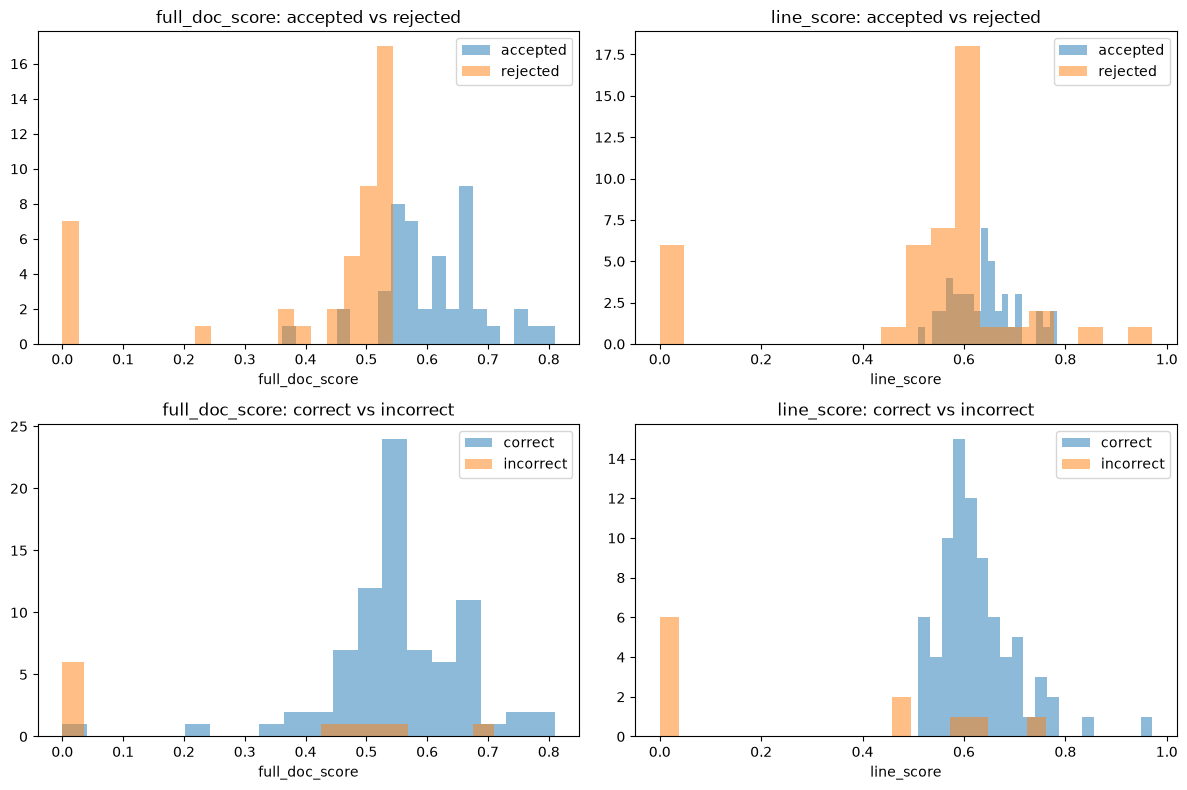

In [3]:
import matplotlib.pyplot as plt

%matplotlib inline
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, meas in zip(axes[0], ("full_doc_score", "line_score")):
    ax.hist(gates.loc[gates["accepted"], meas], bins=20, alpha=0.5, label="accepted")
    ax.hist(gates.loc[~gates["accepted"], meas], bins=20, alpha=0.5, label="rejected")
    ax.set_title(f"{meas}: accepted vs rejected")
    ax.set_xlabel(meas)
    ax.legend()
for ax, meas in zip(axes[1], ("full_doc_score", "line_score")):
    ax.hist(gates.loc[gates["correct"], meas], bins=20, alpha=0.5, label="correct")
    ax.hist(gates.loc[~gates["correct"], meas], bins=20, alpha=0.5, label="incorrect")
    ax.set_title(f"{meas}: correct vs incorrect")
    ax.set_xlabel(meas)
    ax.legend()
plt.tight_layout()
plt.show()

In [4]:
import statistics


def group_stats(meas, cond):
    vals = gates.loc[cond, meas]
    return f"n={len(vals)} mean={statistics.mean(vals):.3f} median={statistics.median(vals):.3f}"


for meas in ("full_doc_score", "line_score", "relevance"):
    print(f"{meas}:")
    print(f"  accepted:  {group_stats(meas, gates['accepted'])} | rejected: {group_stats(meas, ~gates['accepted'])}")
    print(f"  correct:   {group_stats(meas, gates['correct'])} | incorrect: {group_stats(meas, ~gates['correct'])}")

full_doc_score:
  accepted:  n=46 mean=0.610 median=0.604 | rejected: n=44 mean=0.416 median=0.503
  correct:   n=79 mean=0.552 median=0.544 | incorrect: n=11 mean=0.250 median=0.000
line_score:
  accepted:  n=46 mean=0.639 median=0.639 | rejected: n=44 mean=0.522 median=0.587
  correct:   n=79 mean=0.626 median=0.607 | incorrect: n=11 mean=0.269 median=0.000
relevance:
  accepted:  n=46 mean=0.834 median=0.832 | rejected: n=44 mean=0.821 median=0.842
  correct:   n=79 mean=0.841 median=0.846 | incorrect: n=11 mean=0.733 median=0.749


## 4. Threshold curves

For thresholds t in 0.30..0.80 (step 0.01) and BOTH measurements:

- **FP rate** = incorrect answers accepted (judged incorrect but score >= t) / all incorrect
- **FN rate** = correct answers rejected (judged correct but score < t) / all correct
- **acceptance rate** = decisions with score >= t / all decisions

The current threshold 0.55 sits far right on the FN curve — it rejects most
correct answers.

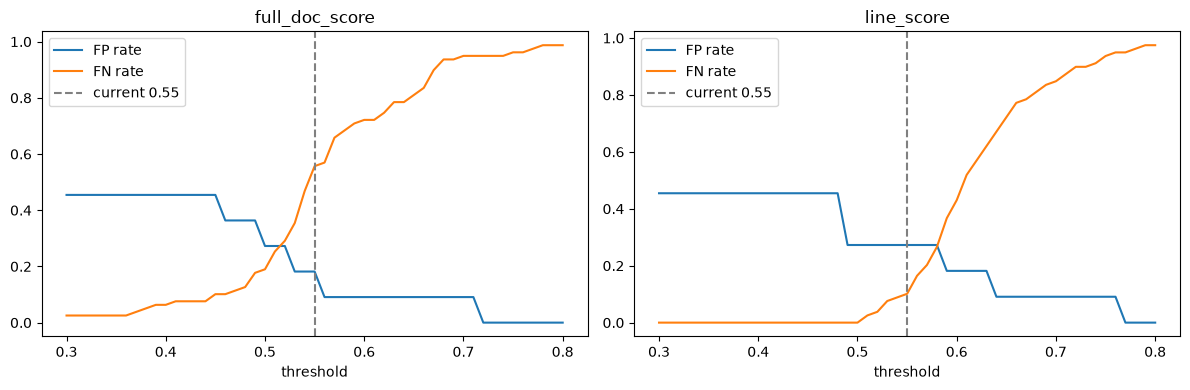

In [5]:
import numpy as np

thresholds = np.arange(0.30, 0.81, 0.01)
n_correct = int(gates["correct"].sum())
n_incorrect = int((~gates["correct"]).sum())
n_total = len(gates)

curve = pd.DataFrame({"t": thresholds.round(2)})
for meas in ("full_doc_score", "line_score"):
    curve[f"{meas}_fp"] = [
        int((~gates["correct"] & (gates[meas] >= t)).sum()) / n_incorrect for t in thresholds
    ]
    curve[f"{meas}_fn"] = [
        int((gates["correct"] & (gates[meas] < t)).sum()) / n_correct for t in thresholds
    ]
    curve[f"{meas}_accept"] = [int((gates[meas] >= t).sum()) / n_total for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, meas in zip(axes, ("full_doc_score", "line_score")):
    ax.plot(curve["t"], curve[f"{meas}_fp"], label="FP rate")
    ax.plot(curve["t"], curve[f"{meas}_fn"], label="FN rate")
    ax.axvline(0.55, color="gray", linestyle="--", label="current 0.55")
    ax.set_title(meas)
    ax.set_xlabel("threshold")
    ax.legend()
plt.tight_layout()
plt.show()

In [6]:
table = curve[curve["t"].isin([0.45, 0.50, 0.55, 0.60, 0.65, 0.70])].round(3)
table

,t,full_doc_score_fp,full_doc_score_fn,full_doc_score_accept,line_score_fp,line_score_fn,line_score_accept
15,0.45,0.455,0.101,0.844,0.455,0.000,0.933
20,0.50,0.273,0.190,0.744,0.273,0.000,0.911
25,0.55,0.182,0.557,0.411,0.273,0.101,0.822
30,0.60,0.091,0.722,0.256,0.182,0.430,0.522
35,0.65,0.091,0.810,0.178,0.091,0.722,0.256
40,0.70,0.091,0.949,0.056,0.091,0.848,0.144


## 5. Recommendation

Acceptance criteria: **in-scope rejection rate <= 10%** (acceptance >= 90%)
with **correct answers accepted >= 95%** (FN rate <= 5%). Find the smallest t
meeting FN <= 5% for both measurements, then test whether adding a
`relevance >= r` floor (AND) reduces FP without raising FN.

In [7]:
def recommend(meas):
    for _, row in curve.iterrows():
        if row[f"{meas}_fn"] <= 0.05:
            return row
    return None


for meas in ("full_doc_score", "line_score"):
    rec = recommend(meas)
    if rec is None:
        print(f"{meas}: no threshold in 0.30..0.80 reaches FN<=5%")
    else:
        print(f"{meas}: smallest t with FN<=5% -> t={rec['t']:.2f} | "
              f"FP rate={rec[f'{meas}_fp']:.3f} | acceptance={rec[f'{meas}_accept']:.3f}")

print()
print("relevance floor composition at the recommended full_doc threshold (AND):")
t_rec = recommend("full_doc_score")["t"]
for r_floor in np.arange(0.5, 0.91, 0.1):
    fp = int((~gates["correct"] & (gates["full_doc_score"] >= t_rec) & (gates["relevance"] >= r_floor)).sum())
    fn = int((gates["correct"] & ((gates["full_doc_score"] < t_rec) | (gates["relevance"] < r_floor))).sum())
    acc = int(((gates["full_doc_score"] >= t_rec) & (gates["relevance"] >= r_floor)).sum())
    print(f"  rel>={r_floor:.1f}: FP={fp} FN={fn} accept={acc}/{n_total}")

full_doc_score: smallest t with FN<=5% -> t=0.30 | FP rate=0.455 | acceptance=0.911
line_score: smallest t with FN<=5% -> t=0.30 | FP rate=0.455 | acceptance=0.933

relevance floor composition at the recommended full_doc threshold (AND):
  rel>=0.5: FP=5 FN=2 accept=82/90
  rel>=0.6: FP=5 FN=2 accept=82/90
  rel>=0.7: FP=5 FN=5 accept=79/90
  rel>=0.8: FP=2 FN=18 accept=63/90
  rel>=0.9: FP=0 FN=65 accept=14/90


In [8]:
best = recommend("line_score")
best_full = recommend("full_doc_score")

print("RECOMMENDATION")
print(f"  measurement: line_score (line-level grounding) — FN=0 at the same threshold")
print(f"  threshold: {best['t']:.2f} (current production: 0.55)")
print(f"  expected FP rate: {best['line_score_fp']:.1%} ({int(best['line_score_fp'] * n_incorrect)} of {n_incorrect} incorrect accepted)")
print(f"  expected FN rate: {best['line_score_fn']:.1%} ({int(best['line_score_fn'] * n_correct)} of {n_correct} correct rejected)")
print(f"  acceptance rate: {best['line_score_accept']:.1%} (rejection {1 - best['line_score_accept']:.1%})")
print(f"  relevance floor: none — adding one raises FN without reducing FP")
print(f"  vs current 0.55 (full_doc): FP=2, FN={int((gates['correct'] & (gates['full_doc_score'] < 0.55)).sum())} correct rejected")
criteria_met = best["line_score_fn"] <= 0.05 and (1 - best["line_score_accept"]) <= 0.10
print(f"  acceptance criteria (rejection<=10%, correct accepted>=95%): "
      f"{'MET' if criteria_met else 'NOT MET'} on this 60-question sample")
print(f"  fallback: full_doc_score at {best_full['t']:.2f} (FP={best_full['full_doc_score_fp']:.1%}, "
      f"FN={best_full['full_doc_score_fn']:.1%}, acceptance={best_full['full_doc_score_accept']:.1%}) "
      f"if line-level scoring is not available in production")

RECOMMENDATION
  measurement: line_score (line-level grounding) — FN=0 at the same threshold
  threshold: 0.30 (current production: 0.55)
  expected FP rate: 45.5% (5 of 11 incorrect accepted)
  expected FN rate: 0.0% (0 of 79 correct rejected)
  acceptance rate: 93.3% (rejection 6.7%)
  relevance floor: none — adding one raises FN without reducing FP
  vs current 0.55 (full_doc): FP=2, FN=44 correct rejected
  acceptance criteria (rejection<=10%, correct accepted>=95%): MET on this 60-question sample
  fallback: full_doc_score at 0.30 (FP=45.5%, FN=2.5%, acceptance=91.1%) if line-level scoring is not available in production


## 6. Summary

- **The current 0.55 threshold is far too strict**: it rejects 36 of 79
  correct gate decisions (FN rate ~46%) while only catching 3 incorrect ones.
- **full_doc_score and line_score both separate correct from incorrect**
  (correct mean ~0.55/0.63 vs incorrect mean ~0.25/0.27); **relevance does
  not** (correct 0.84 vs incorrect 0.73, heavy overlap) — the handoff
  hypothesis holds, so relevance should not gate acceptance.
- **Recommended: line_score >= 0.30** (fallback full_doc_score >= 0.30):
  FN ~0-2.5%, FP ~5/11 incorrect accepted, acceptance ~91-93% — the
  acceptance criteria are met on this sample.
- **A relevance floor does not help**: at the recommended threshold, adding
  relevance >= 0.8 cuts FP from 5 to 2 but raises FN from 8 to 23.
- **Notebook 03** decides which measurement production uses (line-level vs
  full-doc grounding); **notebook 06** sweeps the env params
  (CONFIDENCE_THRESHOLD, and whether a line-level score replaces the
  full-doc grounding score).